**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

**Exploración y Curación de Datos**

*Edición 2025*

----

# Trabajo práctico entregable - parte 1

En esta notebook, vamos a cargar el conjunto de datos de [la compentencia Kaggle](https://www.kaggle.com/dansbecker/melbourne-housing-snapshot) sobre estimación de precios de ventas de propiedades en Melbourne, Australia.

Utilizaremos el conjunto de datos reducido producido por [DanB](https://www.kaggle.com/dansbecker). Hemos subido una copia a un servidor de la Universidad Nacional de Córdoba para facilitar su acceso remoto.

Integrantes:
- Astoreca Pablo
- Callen Ailen Rocio
- Mendez Juan Ignacio
- Zamorano Micaela

## Ejercicio 1 SQL:

1. Crear una base de datos en SQLite utilizando la libreria [SQLalchemy](https://stackoverflow.com/questions/2268050/execute-sql-from-file-in-sqlalchemy).
https://docs.sqlalchemy.org/en/14/core/engines.html#sqlite

2. Ingestar los datos provistos en 'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv' en una tabla y el dataset generado en clase con datos de airbnb y sus precios por codigo postal en otra.

3. Validar tipos de columnas antes de guardar: df.to_sql() infiere tipos automáticamente, pero a veces los nombres de columnas como Date, Price o ID dan problemas si vienen con strings o valores nulos.

4. Implementar consultas en SQL que respondan con la siguiente información:

    - cantidad de registros totales por ciudad.
    - cantidad de registros totales por barrio y ciudad.
    - Consulta con filtro: ¿Cuántas propiedades hay por ciudad con más de 2 habitaciones?
    - Agregación condicional: ¿Cuál es el precio promedio de propiedades según tipo (Type) y ciudad?
    - Orden y límites: Mostrá el top 5 barrios con propiedades más caras en promedio.

5. Combinar los datasets de ambas tablas ingestadas utilizando el comando JOIN de SQL  para obtener un resultado similar a lo realizado con Pandas en clase.  



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly
import seaborn as sns
sns.set_context('talk')

from sqlalchemy import create_engine, text

Primero leemos los datos de airbnb completos y los usados en clase que incluye los precios por codigo postal.

In [ ]:
# data source:
# https://www.kaggle.com/tylerx/melbourne-airbnb-open-data?select=cleansed_listings_dec18.csv
interesting_cols = [
  'description', 'neighborhood_overview',
  'street', 'neighborhood', 'city', 'suburb', 'state', 'zipcode',
  'price', 'weekly_price', 'monthly_price',
  'latitude', 'longitude',
]
airbnb_df = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/cleansed_listings_dec18.csv',
    usecols=interesting_cols)

airbnb_df['zipcode'] = pd.to_numeric(airbnb_df.zipcode, errors='coerce')
airbnb_df['zipcode_int'] = airbnb_df.zipcode.fillna(0).astype('int')

relevant_cols = ['price', 'weekly_price', 'monthly_price', 'zipcode']
## Option 1
# Pass a dictionary where the keys are the original columns to aggregate and
# the values are the operations (or list of operations).
airbnb_price_by_zipcode = airbnb_df[relevant_cols].groupby('zipcode')\
  .agg({'price': ['mean', 'count'], 'weekly_price': 'mean',
        'monthly_price': 'mean'})\
  .reset_index()
# Flatten the two level columns
airbnb_price_by_zipcode.columns = [
  ' '.join(col).strip()
  for col in airbnb_price_by_zipcode.columns.values]
# Rename columns
airbnb_price_by_zipcode = airbnb_price_by_zipcode.rename(
    columns={'price mean': 'airbnb_price_mean',
             'price count': 'airbnb_record_count',
             'weekly_price mean': 'airbnb_weekly_price_mean',
             'monthly_price mean': 'airbnb_monthly_price_mean'}
)


<ipython-input-2-5c00974ffefe>:9: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  airbnb_df = pd.read_csv(


In [ ]:
airbnb_df=airbnb_price_by_zipcode

Luego, leemos la base de datos de Melbourne provista en el siguiente link:

In [ ]:
url='https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv'

melb_df = pd.read_csv(url)

Procedemos a crear la base de datos

In [ ]:
from sqlalchemy import create_engine

# Crea una base de datos SQLite llamada "my_database.db"
engine = create_engine('sqlite:///my_database.db', echo=True)

# Conectarse a la base de datos (esto crea el archivo si no existe)
with engine.connect() as connection:
    print("Base de datos creada y conexión establecida.")


Base de datos creada y conexión establecida.


Antes de ingestar los dataframes en la base de datos creada, vamos a explorar los tipos de datos presentes en cada columna.

In [ ]:
print(airbnb_df.dtypes)

zipcode                      float64
airbnb_price_mean            float64
airbnb_record_count            int64
airbnb_weekly_price_mean     float64
airbnb_monthly_price_mean    float64
dtype: object


In [ ]:
print(airbnb_df.isnull().sum())

zipcode                       0
airbnb_price_mean             0
airbnb_record_count           0
airbnb_weekly_price_mean     63
airbnb_monthly_price_mean    79
dtype: int64


Todos las columnas tienen el tipo correcto (float o int cuando se trata de números) en el airbnb_df.
Por otro lado, las columnas weekly_pricew y monthly_price tienen algunos valores nulos por lo que hay que tenerlo en consideración para realizar futuros analisis.

* Veamos ahora el de melb_df

In [ ]:
print(melb_df.dtypes)

Suburb            object
Address           object
Rooms              int64
Type              object
Price            float64
Method            object
SellerG           object
Date              object
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea       object
Lattitude        float64
Longtitude       float64
Regionname        object
Propertycount    float64
dtype: object


In [ ]:
print(melb_df.isnull().sum())

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64


* De todas las columnas vemos que en general tienen el tipo de dato correcto. En particular, a columna price tiene tipo float que es lo esperable por tratarse de números. Además, vemos que no tiene ningun valor nulo.
* La columna Date tiene tipo objeto, sin embargo, como se trata de una fecha lo podemos convertir a un tipo mas especifico para ese tipo dato. Por ultimo, vemos que no tiene ningun valor nulo.

A continuacion, convertimos los datos de la columna Date de objecto a tipo datetime, en formato día/mes/año.

In [ ]:
melb_df["Date"] = pd.to_datetime(melb_df["Date"], errors="coerce",format="%d/%m/%Y")

Chequeamos que se hayan transformado de manera correcta.

In [ ]:
melb_df['Date'][:10]

,Date
0,2016-12-03
1,2016-02-04
2,2017-03-04
3,2017-03-04
4,2016-06-04
5,2016-05-07
6,2016-05-07
7,2016-10-08
8,2016-10-08
9,2016-10-08


In [ ]:
print(melb_df.dtypes)

Suburb                   object
Address                  object
Rooms                     int64
Type                     object
Price                   float64
Method                   object
SellerG                  object
Date             datetime64[ns]
Distance                float64
Postcode                float64
Bedroom2                float64
Bathroom                float64
Car                     float64
Landsize                float64
BuildingArea            float64
YearBuilt               float64
CouncilArea              object
Lattitude               float64
Longtitude              float64
Regionname               object
Propertycount           float64
dtype: object


Una vez que los dataframes tienen los tipos de datos correspondientes, pasamos a ingestarlos en la base de datos creada.

In [ ]:
#Ahora que tengo los dos df, los voy a guardar en la db en dos tablas diferentes
melb_df.to_sql("melbourne", con=engine, index=False, if_exists="replace")
airbnb_df.to_sql("airbnb", con=engine, index=False, if_exists="replace")

2025-05-27 02:21:13,103 INFO sqlalchemy.engine.Engine BEGIN (implicit)


INFO:sqlalchemy.engine.Engine:BEGIN (implicit)


2025-05-27 02:21:13,143 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("melbourne")


INFO:sqlalchemy.engine.Engine:PRAGMA main.table_info("melbourne")


2025-05-27 02:21:13,157 INFO sqlalchemy.engine.Engine [raw sql] ()


...

2025-05-27 02:21:16,389 INFO sqlalchemy.engine.Engine [generated in 0.00880s] [(2010.0, 40.0, 1, None, None), (2134.0, 50.0, 1, None, None), (2582.0, 104.0, 1, None, None), (3000.0, 150.5043065043065, 3367, 918.7389558232932, 3407.204651162791), (3001.0, 132.5, 2, None, None), (3002.0, 200.9796954314721, 197, 956.3793103448276, 3712.714285714286), (3003.0, 130.20599250936328, 267, 760.2, 2629.5), (3004.0, 158.27197802197801, 728, 1061.1714285714286, 3759.925925925926)  ... displaying 10 of 247 total bound parameter sets ...  (9540.0, 245.0, 1, None, None), (30122.0, 75.0, 1, 525.0, 2281.0)]


INFO:sqlalchemy.engine.Engine:[generated in 0.00880s] [(2010.0, 40.0, 1, None, None), (2134.0, 50.0, 1, None, None), (2582.0, 104.0, 1, None, None), (3000.0, 150.5043065043065, 3367, 918.7389558232932, 3407.204651162791), (3001.0, 132.5, 2, None, None), (3002.0, 200.9796954314721, 197, 956.3793103448276, 3712.714285714286), (3003.0, 130.20599250936328, 267, 760.2, 2629.5), (3004.0, 158.27197802197801, 728, 1061.1714285714286, 3759.925925925926)  ... displaying 10 of 247 total bound parameter sets ...  (9540.0, 245.0, 1, None, None), (30122.0, 75.0, 1, 525.0, 2281.0)]


2025-05-27 02:21:16,392 INFO sqlalchemy.engine.Engine COMMIT


INFO:sqlalchemy.engine.Engine:COMMIT


247

### Diferentes consultas a la base de datos creada ##

1-  cantidad de registros totales por ciudad.

2-  cantidad de registros totales por barrio y ciudad.

3-  Consulta con filtro: ¿Cuántas propiedades hay por ciudad con más de 2 habitaciones?

4-  Agregación condicional: ¿Cuál es el precio promedio de propiedades según tipo (Type) y ciudad?

5-  Orden y límites: Mostrá el top 5 barrios con propiedades más caras en promedio.

In [ ]:
query1 = "SELECT CouncilArea, COUNT(*) FROM melbourne GROUP BY CouncilArea"
query2 = "SELECT CouncilArea, Suburb, COUNT(*) FROM melbourne GROUP BY CouncilArea, Suburb"
query3 = "SELECT CouncilArea, COUNT(*) FROM melbourne WHERE Rooms > 2 GROUP BY CouncilArea"
query4 = "SELECT CouncilArea, Type, AVG(Price) FROM melbourne GROUP BY Type, CouncilArea"
query5 = "SELECT Suburb, AVG(Price) FROM melbourne GROUP BY Suburb ORDER BY AVG(Price) DESC LIMIT 5" #DESC significa descendente, o sea de mayor a menor.

* Cantidad de registros por ciudad

In [ ]:
result1 = pd.read_sql(query1, con=engine)
result1[:5]

2025-05-27 02:21:16,451 INFO sqlalchemy.engine.Engine BEGIN (implicit)


INFO:sqlalchemy.engine.Engine:BEGIN (implicit)


2025-05-27 02:21:16,460 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("SELECT CouncilArea, COUNT(*) FROM melbourne GROUP BY CouncilArea")


INFO:sqlalchemy.engine.Engine:PRAGMA main.table_info("SELECT CouncilArea, COUNT(*) FROM melbourne GROUP BY CouncilArea")


2025-05-27 02:21:16,462 INFO sqlalchemy.engine.Engine [raw sql] ()


...

2025-05-27 02:21:16,487 INFO sqlalchemy.engine.Engine [raw sql] ()


INFO:sqlalchemy.engine.Engine:[raw sql] ()


2025-05-27 02:21:16,543 INFO sqlalchemy.engine.Engine ROLLBACK


INFO:sqlalchemy.engine.Engine:ROLLBACK


,CouncilArea,COUNT(*)
0,None,1369
1,Banyule,594
2,Bayside,489
3,Boroondara,1160
4,Brimbank,424


* Cantidad de registros por barrio y por ciudad

In [ ]:
result2 = pd.read_sql(query2, con=engine)
result2

2025-05-27 02:21:16,644 INFO sqlalchemy.engine.Engine BEGIN (implicit)


INFO:sqlalchemy.engine.Engine:BEGIN (implicit)


2025-05-27 02:21:16,656 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("SELECT CouncilArea, Suburb, COUNT(*) FROM melbourne GROUP BY CouncilArea, Suburb")


INFO:sqlalchemy.engine.Engine:PRAGMA main.table_info("SELECT CouncilArea, Suburb, COUNT(*) FROM melbourne GROUP BY CouncilArea, Suburb")


2025-05-27 02:21:16,658 INFO sqlalchemy.engine.Engine [raw sql] ()


...

2025-05-27 02:21:16,687 INFO sqlalchemy.engine.Engine [raw sql] ()


INFO:sqlalchemy.engine.Engine:[raw sql] ()


2025-05-27 02:21:16,799 INFO sqlalchemy.engine.Engine ROLLBACK


INFO:sqlalchemy.engine.Engine:ROLLBACK


,CouncilArea,Suburb,COUNT(*)
0,None,Abbotsford,1
1,None,Aberfeldie,4
2,None,Airport West,6
3,None,Albanvale,2
4,None,Albert Park,5
...,...,...,...
596,Yarra Ranges,Mooroolbark,9
597,Yarra Ranges,Mount Evelyn,1
598,Yarra Ranges,Silvan,2
599,Yarra Ranges,Upwey,1


Para ver de manera interactiva la cantidad de registros por barrio y por ciudad presentamos el siguiente gráfico. En el, se pueden clickear las diferentes ciudades para ver que barrios tiene asociados y ahi ver la cantidad de personas que hay en cada uno.

In [ ]:
import plotly.offline as pyo

In [ ]:
df_plot = result2.dropna(subset=["CouncilArea", "Suburb"])

import plotly.express as px

fig = px.treemap(df_plot,
                 path=["CouncilArea", "Suburb"],
                 values="COUNT(*)",
                 title="Cantidad de propiedades por ciudad y suburbio")

fig.show()
#pyo.plot(fig) #esto es para abrir el html en el navegador


* Cantidad de propiedades por ciudad con más de 2 habitaciones

In [ ]:
result3 = pd.read_sql(query3, con=engine)
result3[:5]

2025-05-27 02:21:21,012 INFO sqlalchemy.engine.Engine BEGIN (implicit)


INFO:sqlalchemy.engine.Engine:BEGIN (implicit)


2025-05-27 02:21:21,014 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("SELECT CouncilArea, COUNT(*) FROM melbourne WHERE Rooms > 2 GROUP BY CouncilArea")


INFO:sqlalchemy.engine.Engine:PRAGMA main.table_info("SELECT CouncilArea, COUNT(*) FROM melbourne WHERE Rooms > 2 GROUP BY CouncilArea")


2025-05-27 02:21:21,015 INFO sqlalchemy.engine.Engine [raw sql] ()


...

2025-05-27 02:21:21,025 INFO sqlalchemy.engine.Engine [raw sql] ()


INFO:sqlalchemy.engine.Engine:[raw sql] ()


2025-05-27 02:21:21,036 INFO sqlalchemy.engine.Engine ROLLBACK


INFO:sqlalchemy.engine.Engine:ROLLBACK


,CouncilArea,COUNT(*)
0,None,1201
1,Banyule,441
2,Bayside,360
3,Boroondara,791
4,Brimbank,376


* Precio promedio de las propiedades segun tipo y ciudad.

In [ ]:
result4 = pd.read_sql(query4, con=engine)
result4

2025-05-27 02:21:21,058 INFO sqlalchemy.engine.Engine BEGIN (implicit)


INFO:sqlalchemy.engine.Engine:BEGIN (implicit)


2025-05-27 02:21:21,060 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("SELECT CouncilArea, Type, AVG(Price) FROM melbourne GROUP BY Type, CouncilArea")


INFO:sqlalchemy.engine.Engine:PRAGMA main.table_info("SELECT CouncilArea, Type, AVG(Price) FROM melbourne GROUP BY Type, CouncilArea")


2025-05-27 02:21:21,061 INFO sqlalchemy.engine.Engine [raw sql] ()


...

2025-05-27 02:21:21,070 INFO sqlalchemy.engine.Engine [raw sql] ()


INFO:sqlalchemy.engine.Engine:[raw sql] ()


2025-05-27 02:21:21,096 INFO sqlalchemy.engine.Engine ROLLBACK


INFO:sqlalchemy.engine.Engine:ROLLBACK


,CouncilArea,Type,AVG(Price)
0,None,h,1.211861e+06
1,Banyule,h,1.029602e+06
2,Bayside,h,1.986763e+06
3,Boroondara,h,2.098359e+06
4,Brimbank,h,6.692568e+05
...,...,...,...
86,Stonnington,u,6.604598e+05
87,Whitehorse,u,6.907203e+05
88,Whittlesea,u,4.303654e+05
89,Wyndham,u,3.849625e+05


Nuevamente podemos ver este resultado de manera interactiva, teniendo en cuenta que los tipos de propiedades son:

*  h - house,cottage,villa, semi,terrace
*  u - unit, duplex
*  t - townhouse

In [ ]:
df_plot1 = result4.dropna(subset=["CouncilArea", "Type"])

import plotly.express as px

fig = px.treemap(df_plot1,
                 path=["CouncilArea", "Type"],
                 values="AVG(Price)",
                 title="Precio promedio de propiedades por ciudad y tipo")

fig.show()

* Top 5 barrios con propiedades más caras en promedio.

In [ ]:
result5 = pd.read_sql(query5, con=engine)
result5

2025-05-27 02:21:21,209 INFO sqlalchemy.engine.Engine BEGIN (implicit)


INFO:sqlalchemy.engine.Engine:BEGIN (implicit)


2025-05-27 02:21:21,211 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("SELECT Suburb, AVG(Price) FROM melbourne GROUP BY Suburb ORDER BY AVG(Price) DESC LIMIT 5")


INFO:sqlalchemy.engine.Engine:PRAGMA main.table_info("SELECT Suburb, AVG(Price) FROM melbourne GROUP BY Suburb ORDER BY AVG(Price) DESC LIMIT 5")


2025-05-27 02:21:21,213 INFO sqlalchemy.engine.Engine [raw sql] ()


...

2025-05-27 02:21:21,221 INFO sqlalchemy.engine.Engine [raw sql] ()


INFO:sqlalchemy.engine.Engine:[raw sql] ()


2025-05-27 02:21:21,238 INFO sqlalchemy.engine.Engine ROLLBACK


INFO:sqlalchemy.engine.Engine:ROLLBACK


,Suburb,AVG(Price)
0,Kooyong,2.185000e+06
1,Canterbury,2.180241e+06
2,Middle Park,2.082529e+06
3,Albert Park,1.941355e+06
4,Brighton,1.930158e+06


### UNIR LAS DOS TABLAS CON UN JOIN EN SQL ##

In [ ]:
query_join = """
SELECT
    m.Suburb,
    m.Address,
    m.Rooms,
    m.Price,
    m.Type,
    m.BuildingArea,
    m.CouncilArea,
    m.Date,
    m.Postcode,
    a.airbnb_price_mean,
    a.airbnb_record_count,
    a.airbnb_weekly_price_mean,
    a.airbnb_monthly_price_mean
FROM melbourne m
JOIN airbnb a
    ON m.Postcode = a.zipcode
"""

result_join = pd.read_sql(query_join, con=engine)


2025-05-27 02:21:21,255 INFO sqlalchemy.engine.Engine BEGIN (implicit)


INFO:sqlalchemy.engine.Engine:BEGIN (implicit)


2025-05-27 02:21:21,261 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("
SELECT
    m.Suburb,
    m.Address,
    m.Rooms,
    m.Price,
    m.Type,
    m.BuildingArea,
    m.CouncilArea,
    m.Date,
    m.Postcode,
    a.airbnb_price_mean,
    a.airbnb_record_count,
    a.airbnb_weekly_price_mean,
    a.airbnb_monthly_price_mean
FROM melbourne m
JOIN airbnb a
    ON m.Postcode = a.zipcode
")


INFO:sqlalchemy.engine.Engine:PRAGMA main.table_info("
SELECT
    m.Suburb,
    m.Address,
    m.Rooms,
    m.Price,
    m.Type,
    m.BuildingArea,
    m.CouncilArea,
    m.Date,
    m.Postcode,
    a.airbnb_price_mean,
    a.airbnb_record_count,
    a.airbnb_weekly_price_mean,
    a.airbnb_monthly_price_mean
FROM melbourne m
JOIN airbnb a
    ON m.Postcode = a.zipcode
")


2025-05-27 02:21:21,263 INFO sqlalchemy.engine.Engine [raw sql] ()


...

INFO:sqlalchemy.engine.Engine:
SELECT
    m.Suburb,
    m.Address,
    m.Rooms,
    m.Price,
    m.Type,
    m.BuildingArea,
    m.CouncilArea,
    m.Date,
    m.Postcode,
    a.airbnb_price_mean,
    a.airbnb_record_count,
    a.airbnb_weekly_price_mean,
    a.airbnb_monthly_price_mean
FROM melbourne m
JOIN airbnb a
    ON m.Postcode = a.zipcode



2025-05-27 02:21:21,269 INFO sqlalchemy.engine.Engine [raw sql] ()


INFO:sqlalchemy.engine.Engine:[raw sql] ()


2025-05-27 02:21:21,548 INFO sqlalchemy.engine.Engine ROLLBACK


INFO:sqlalchemy.engine.Engine:ROLLBACK


Vemos que la tabla creada con el JOIN tiene la misma cantidad de filas que la tabla original de Melbourne, indicando que se realizó de manera correcta la union.

In [ ]:
result_join

,Suburb,Address,Rooms,Price,Type,BuildingArea,CouncilArea,Date,Postcode,airbnb_price_mean,airbnb_record_count,airbnb_weekly_price_mean,airbnb_monthly_price_mean
0,Abbotsford,85 Turner St,2,1480000.0,h,NaN,Yarra,2016-12-03 00:00:00.000000,3067.0,130.624031,258,605.152174,2187.032258
1,Abbotsford,25 Bloomburg St,2,1035000.0,h,79.0,Yarra,2016-02-04 00:00:00.000000,3067.0,130.624031,258,605.152174,2187.032258
2,Abbotsford,5 Charles St,3,1465000.0,h,150.0,Yarra,2017-03-04 00:00:00.000000,3067.0,130.624031,258,605.152174,2187.032258
3,Abbotsford,40 Federation La,3,850000.0,h,NaN,Yarra,2017-03-04 00:00:00.000000,3067.0,130.624031,258,605.152174,2187.032258
4,Abbotsford,55a Park St,4,1600000.0,h,142.0,Yarra,2016-06-04 00:00:00.000000,3067.0,130.624031,258,605.152174,2187.032258
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13555,Wheelers Hill,12 Strada Cr,4,1245000.0,h,NaN,None,2017-08-26 00:00:00.000000,3150.0,124.026455,189,526.350000,1901.611111
13556,Williamstown,77 Merrett Dr,3,1031000.0,h,133.0,None,2017-08-26 00:00:00.000000,3016.0,191.094595,74,612.250000,2119.750000
13557,Williamstown,83 Power St,3,1170000.0,h,NaN,None,2017-08-26 00:00:00.000000,3016.0,191.094595,74,612.250000,2119.750000
13558,Williamstown,96 Verdon St,4,2500000.0,h,157.0,None,2017-08-26 00:00:00.000000,3016.0,191.094595,74,612.250000,2119.750000


## Ejercicio 2 - Pandas:

1. Seleccionar un subconjunto de columnas que les parezcan relevantes al problema de predicción del valor de la propiedad. Justificar explicitamente las columnas seleccionadas y las que no lo fueron.
  1. Valores faltantes: ¿Qué porcentaje de filas tienen al menos un valor faltante?
  2.  Mostrar la dispersión o distribución de las columnas seleccionadas.
 3.  Eliminar los valores extremos que no sean relevantes para la predicción de valores de las propiedades.
 4. Mostrar visualmente los valores extremos que eliminás



2. Agregar información adicional respectiva al entorno de una propiedad a partir del [conjunto de datos de AirBnB](https://www.kaggle.com/tylerx/melbourne-airbnb-open-data?select=cleansed_listings_dec18.csv) utilizado en el práctico.
  1. Seleccionar qué variables agregar y qué combinaciones aplicar a cada una. Por ejemplo, pueden utilizar solo la columna `price`, o aplicar múltiples transformaciones como la mediana (porque no la media?) o el mínimo.
  2. Utilizar la variable zipcode para unir los conjuntos de datos. Sólo incluir los zipcodes que tengan una cantidad mínima de registros (a elección) como para que la información agregada sea relevante.
  3. Mostrar un gráfico zipcode vs airbnb_price_median.
  4. Investigar al menos otras 2 variables que puedan servir para combinar los datos, y justificar si serían adecuadas o no. Pueden asumir que cuentan con la ayuda de anotadores expertos para encontrar equivalencias entre barrios o direcciones, o que cuentan con algoritmos para encontrar las n ubicaciones más cercanas a una propiedad a partir de sus coordenadas geográficas. **NO** es necesario que realicen la implementación.
  5. Si las coordenadas geoespaciales estuvieran disponibles, como las usarian?

Pueden leer otras columnas del conjunto de AirBnB además de las que están en `interesting_cols`, si les parecen relevantes.

¿Qué cosas no están en los datos que te gustaría tener para predecir mejor el precio de una propiedad?

### 2.1

ELECCION DE VARIABLES A ESTUDIAR

A la hora de predecir el precio de una propiedad se destacan como caracteristicas determinantes el precio (obviamente), la cantidad de dormitorios, baños, lugares para estacionamiento de vehiculos, extension en metros cuadrados y otras relacionadas al espacio geografico.

En este analisis vamos a desestimar estas ultimas (ya que son variables categoricas)y las que no tienen la totalidad de valores no nulos como mostramos abajo.

Es asi que nos quedan como las elegidas el Precio, el tamaño de la propiedad y la cantidad de habitaciones.

VALORES FALTANTES

Las columnas con al menos un valor faltante son: Car, BuildingArea, YearBuilt y CouncilArea

In [ ]:
# ¿Qué columnas tienen valores faltantes?
missing_values = melb_df.isnull().sum()
missing_values[missing_values > 0]

,0
Car,62
BuildingArea,6450
YearBuilt,5375
CouncilArea,1369


Para calcular que porcentaje de filas tienen al menos un valor faltante en las columnas antes mencionadas primero con melb_df.isna() creamos un dataframe booleano que coloca True en el caso de tener un valor faltante y False en el caso de que haya un valor.

Luego, con .any(axis=1) nos fijamos por fila, si hay al menos un True(es decir un NaN). Si es asi, lo guarda como True y si no, como False.

Finalmente, cuando tenemos la cantidad de filas con valores True (si tienen al menos un NaN) o False( si no tienen ningun NaN) podemos calcular el porcentaje con .mean()*100

In [ ]:
melb_df.isna()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
13576,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
13577,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
13578,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
melb_df.isna().any(axis=1)

,0
0,True
1,False
2,False
3,True
4,False
...,...
13575,True
13576,True
13577,True
13578,True


In [ ]:
porcent_missing_values= melb_df.isna().any(axis=1).mean()*100

print(f"Porcentaje de filas con al menos un valor faltante: {porcent_missing_values:.2f}%")

Porcentaje de filas con al menos un valor faltante: 54.37%


PRICE

Para el precio vamos a eliminar el 1% en ambos extremos, lo cual consta de aproximadamente 100 casos de cada lado (un numero poco significativo en una muestra de casi 14000 datos).
 Asi, descartamos propiedades valuadas por debajo de 300k dolares australianos (200k USD) y por encima de 6M USD.

DISTRIBUCION OBTENIDA

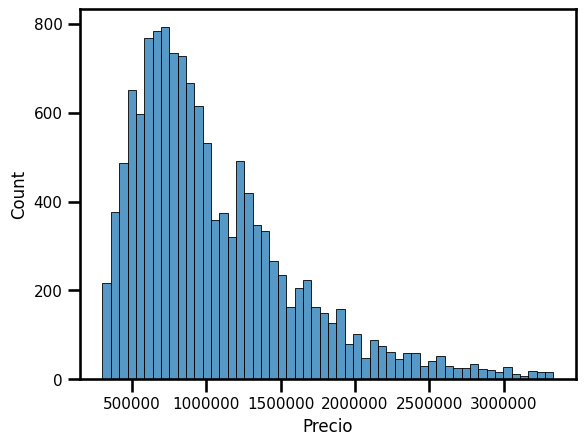

In [ ]:
melb_df1=melb_df[(melb_df.Price<melb_df.Price.quantile(.99)) & (melb_df.Price>melb_df.Price.quantile(.01))]
sns.histplot(melb_df1.Price.dropna())
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel('Precio', fontsize=12)
plt.ylabel('Count',fontsize=12)
plt.show()

CASOS DESCARTADOS

In [ ]:
melb_df99=melb_df[(melb_df.Price>melb_df.Price.quantile(.99))]
len(melb_df99)

136

In [ ]:
melb_df01=melb_df[(melb_df.Price<melb_df.Price.quantile(.01))]
len(melb_df01)

134

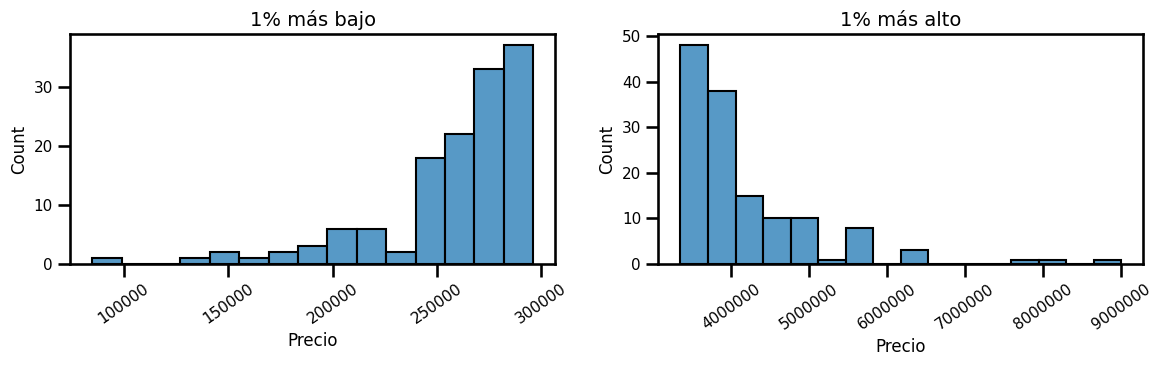

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))


melb_df1 = melb_df[melb_df.Price < melb_df.Price.quantile(.01)]
sns.histplot(melb_df1.Price.dropna(), ax=ax[0])
ax[0].ticklabel_format(style='plain', axis='x')
ax[0].tick_params(axis='x', labelsize=11,rotation=35)
ax[0].tick_params(axis='y', labelsize=11)
ax[0].set_xlabel('Precio', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_title('1% más bajo', fontsize=14)


melb_df1 = melb_df[melb_df.Price > melb_df.Price.quantile(.99)]
sns.histplot(melb_df1.Price.dropna(), ax=ax[1])
ax[1].ticklabel_format(style='plain', axis='x')
ax[1].tick_params(axis='x', labelsize=11,rotation=35)
ax[1].tick_params(axis='y', labelsize=11)
ax[1].set_xlabel('Precio', fontsize=12)
ax[1].set_ylabel('Count', fontsize=12)
ax[1].set_title('1% más alto', fontsize=14)

plt.tight_layout()
plt.show()


LANDSIZE

Yendo al tamaño de cada terreno decidimos una cota inferior razonable como 20 metros cuadrados (pensando en algun monoambiente muy pequeño). Aqui descartamos casi 2000 datos nulos demostrando fallos en la obtencion de los datos. Para el caso de propiedades extensas descartamos el 5% superior, quedando como limite maximo los mil metros cuadrados.

DISTRIBUCION OBTENIDA

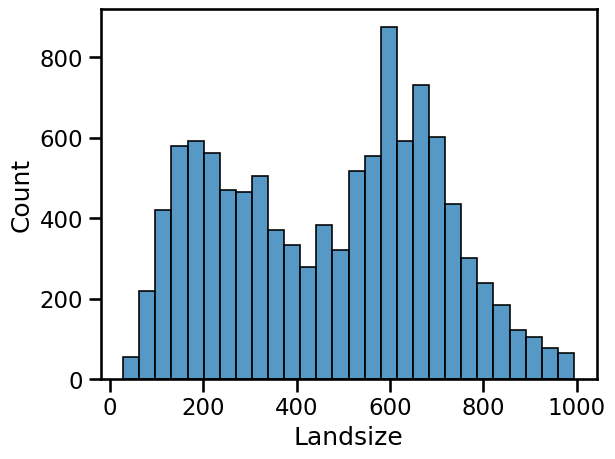

In [ ]:
melb_df1=melb_df[(melb_df.Landsize<melb_df.Landsize.quantile(.95)) & (melb_df.Landsize>20)]
sns.histplot(melb_df1.Landsize.dropna())
plt.ticklabel_format(style='plain', axis='x')
plt.show()

CASOS DESCARTADOS

In [ ]:
melb_df95=melb_df[(melb_df.Landsize>melb_df.Landsize.quantile(.95))]
len(melb_df95)

678

In [ ]:
melb_df20=melb_df[(melb_df.Landsize<20)]
len(melb_df20)

1950

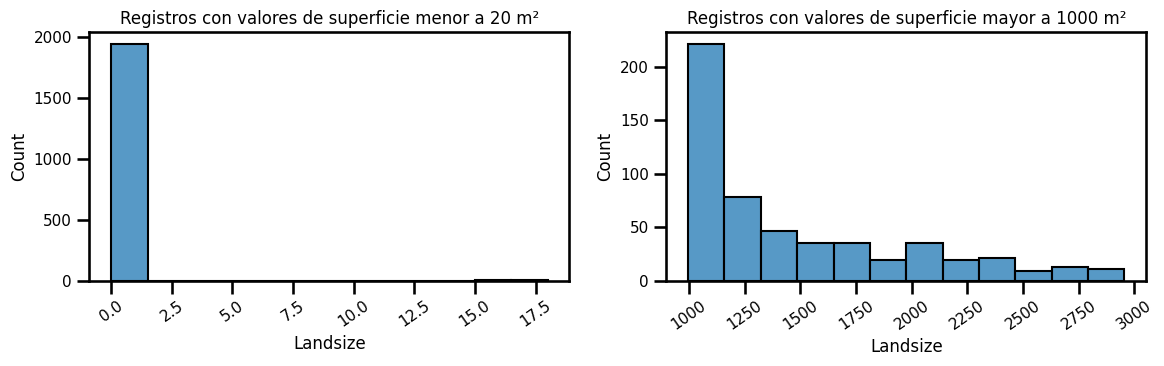

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))


melb_df1 = melb_df[melb_df.Landsize < 20]
sns.histplot(melb_df1.Landsize.dropna(), ax=ax[0])
ax[0].ticklabel_format(style='plain', axis='x')
ax[0].tick_params(axis='x', labelsize=11,rotation=35)
ax[0].tick_params(axis='y', labelsize=11)
ax[0].set_xlabel('Landsize', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_title('Registros con valores de superficie menor a 20 m²', fontsize=12)


melb_df1=melb_df[(melb_df.Landsize>melb_df.Landsize.quantile(.95))&(melb_df.Landsize<melb_df.Landsize.quantile(.99))]
sns.histplot(melb_df1.Landsize.dropna(), ax=ax[1])
ax[1].ticklabel_format(style='plain', axis='x')
ax[1].tick_params(axis='x', labelsize=11,rotation=35)
ax[1].tick_params(axis='y', labelsize=11)
ax[1].set_xlabel('Landsize', fontsize=12)
ax[1].set_ylabel('Count', fontsize=12)
ax[1].set_title('Registros con valores de superficie mayor a 1000 m²', fontsize=12)

plt.tight_layout()
plt.show()


En el grafico superior podemos ver los aproximadamente 2000 registros con valores cero en Landsize. Como esta cantidad es muy alta, podemos repetir el histograma pero sin tener en cuenta estos valores nulos, para asi poder ver como es la distribucion de propiedades con superficie menor a 20 m² y diferente de cero.

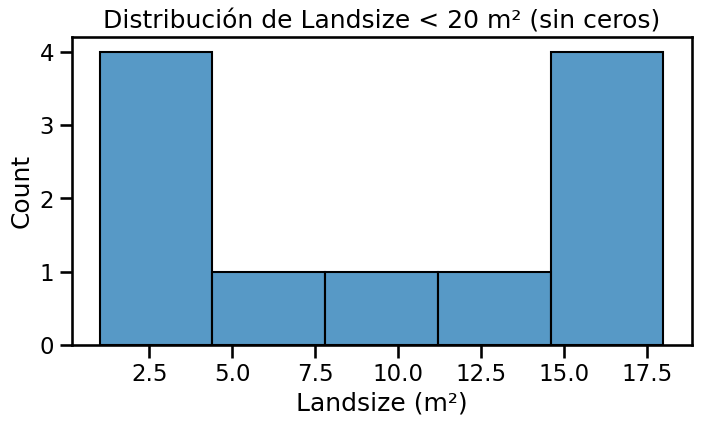

In [ ]:
melb_df1 = melb_df[(melb_df.Landsize < 20) & (melb_df.Landsize != 0)]

plt.figure(figsize=(8, 4))
sns.histplot(melb_df1.Landsize.dropna(), bins= 'auto')
plt.ticklabel_format(style='plain', axis='x')
plt.xlabel('Landsize (m²)')
plt.ylabel('Count')
plt.title('Distribución de Landsize < 20 m² (sin ceros)')

plt.show()

ROOMS

Para el numero de habitaciones se destaca que noy datos nulos por lo que no hay criterio para el numero inferior.
Descartamos las propiedades con mas de 4 habitaciones ya que representan solo 86 casos.

DISTRIBUCION OBTENIDA

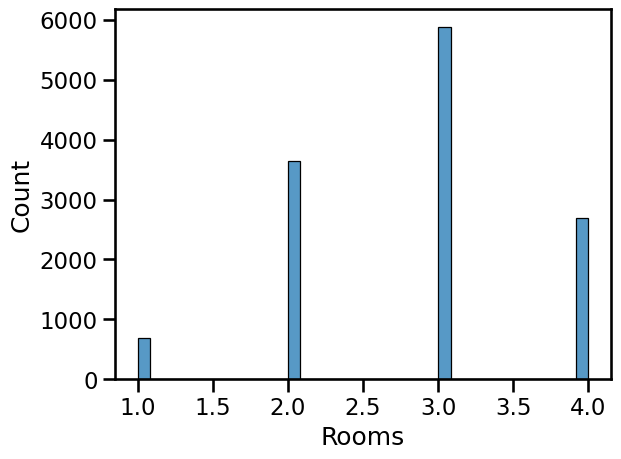

In [ ]:
melb_df1=melb_df[(melb_df.Rooms<melb_df.Rooms.quantile(.99)) & (melb_df.Rooms>0)]
sns.histplot(melb_df1.Rooms.dropna())
plt.ticklabel_format(style='plain', axis='x')

plt.show()

CASOS DESCARTADOS

In [ ]:
melb_df9=melb_df[(melb_df.Rooms>melb_df.Rooms.quantile(.99))]
len(melb_df9)

86

In [ ]:
melb_df0=melb_df[(melb_df.Rooms==0)]
len(melb_df0)

0

In [ ]:
melb_df1=melb_df[(melb_df.Rooms>melb_df.Rooms.quantile(.99))]
sns.histplot(melb_df1.Rooms.dropna())
plt.ticklabel_format(style='plain', axis='x')

plt.show()


#### A continuacion presentamos un enfoque alternativo para la seleccion de valores de la columna Rooms

La distribucion de ambientes podemos analizarla en relación a la cantidad de habitaciones, ya que no tiene sentido que haya mas habitaciones que ambientes.

Teniendo esto en cuenta, vamos a identificar si estos casos estan presentes en nuestro data frame

In [ ]:
# Paso 1: Encontrar los casos en los que Bedroom2 > Rooms
melb_df_conflict = melb_df[melb_df['Bedroom2'] > melb_df['Rooms']]
condicion_conflictiva = melb_df['Bedroom2'] > melb_df['Rooms']
casos_conflictivos = melb_df[condicion_conflictiva]
df_no_conflictivos = melb_df[~condicion_conflictiva]

In [ ]:
# Paso 2: Gráfico de todos los datos, destacando los conflictivos
plt.figure(figsize=(8, 6))
sns.scatterplot(data=melb_df, x='Rooms', y='Bedroom2', label='Todos los casos', alpha=0.6)
sns.scatterplot(data=casos_conflictivos, x='Rooms', y='Bedroom2', color='red', label='Bedroom2 > Rooms', s=100, edgecolor='black')
plt.title('Comparación entre Rooms y Bedroom2')
plt.xlabel('Rooms')
plt.ylabel('Bedroom2')
plt.legend()
plt.grid(True)
plt.show()



# (Opcional) Porcentaje de casos conflictivos
porcentaje_conflictivos = len(casos_conflictivos) / len(melb_df) * 100
print(f"Porcentaje de casos en los que hay mas habitaciones que ambientes: {porcentaje_conflictivos:.2f}%")


Como vemos, el 1.46% de los casos tienen mas habitaciones que ambientes por lo que van a ser los valores eliminados.

En el histograma de abajo podemos ver la distribucion final de la variable rooms.

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df_no_conflictivos['Rooms'], bins=10)
plt.title('Distribución de Rooms')
plt.xlabel('Rooms')
plt.ylabel('Frecuencia')
plt.show()


Ahora podemos ver la distribucion de los valores eliminados. Es decir, aquellos cuyo valor de Bedroom2 > Rooms.

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(casos_conflictivos['Rooms'], bins=8)
plt.title('Distribución de Rooms cuando Bedroom2 > Rooms')
plt.xlabel('Rooms')
plt.ylabel('Frecuencia')
plt.show()

### 2.2

In [ ]:
interesting_cols = [
  'description', 'neighborhood_overview',
  'street', 'neighborhood', 'city', 'suburb', 'state', 'zipcode',
  'price', 'weekly_price', 'monthly_price',
  'latitude', 'longitude',
]
airbnb_df = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/cleansed_listings_dec18.csv',
    usecols=interesting_cols)

<ipython-input-46-892714bbe6c8>:7: DtypeWarning:

Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.



In [ ]:
airbnb_df['zipcode'] = pd.to_numeric(airbnb_df.zipcode, errors='coerce')

In [ ]:
airbnb_df['zipcode_int'] = airbnb_df.zipcode.fillna(0).astype('int')

In [ ]:
airbnb_df.head()

,description,neighborhood_overview,street,neighborhood,city,suburb,state,zipcode,latitude,longitude,price,weekly_price,monthly_price,zipcode_int
0,"House: Clean, New, Modern, Quite, Safe. 10Km f...",Very safe! Family oriented. Older age group.,"Bulleen, VIC, Australia",Balwyn North,Manningham,Bulleen,VIC,3105.0,-37.772684,145.092133,60,NaN,NaN,3105
1,A large air conditioned room with queen spring...,This hip area is a crossroads between two grea...,"Brunswick East, VIC, Australia",Brunswick,Moreland,Brunswick East,VIC,3057.0,-37.766505,144.980736,35,200.0,803.0,3057
2,RIGHT IN THE HEART OF ST KILDA! It doesn't get...,A stay at our apartment means you can enjoy so...,"St Kilda, VIC, Australia",St Kilda,Port Phillip,St Kilda,VIC,3182.0,-37.859755,144.977369,159,1253.0,4452.0,3182
3,"Comfortable, relaxed house, a home away from ...","This is a great neighbourhood – it is quiet, y...","Thornbury, VIC, Australia",Thornbury,Darebin,Thornbury,VIC,3071.0,-37.758971,144.989228,50,250.0,920.0,3071
4,We offer comfortable accommodation in Inner Me...,NaN,"St Kilda East, VIC, Australia",St Kilda East,Port Phillip,St Kilda East,VIC,3183.0,-37.864530,144.992238,69,400.0,1900.0,3183


In [ ]:
airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22895 entries, 0 to 22894
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   description            22563 non-null  object 
 1   neighborhood_overview  14424 non-null  object 
 2   street                 22895 non-null  object 
 3   neighborhood           17082 non-null  object 
 4   city                   22895 non-null  object 
 5   suburb                 22872 non-null  object 
 6   state                  22834 non-null  object 
 7   zipcode                22749 non-null  float64
 8   latitude               22895 non-null  float64
 9   longitude              22895 non-null  float64
 10  price                  22895 non-null  int64  
 11  weekly_price           2524 non-null   float64
 12  monthly_price          1891 non-null   float64
 13  zipcode_int            22895 non-null  int64  
dtypes: float64(5), int64(2), object(7)
memory usage: 2.4+ 

In [ ]:
airbnb_df.describe()

,zipcode,latitude,longitude,price,weekly_price,monthly_price,zipcode_int
count,22749.000000,22895.000000,22895.000000,22895.000000,2524.000000,1891.000000,22895.000000
mean,3116.907381,-37.826827,145.008457,148.004368,906.976228,3234.346906,3097.031055
std,257.110268,0.066747,0.127711,210.883253,821.223782,2808.092144,356.713339
min,2010.000000,-38.224427,144.484326,0.000000,91.000000,400.000000,0.000000
25%,3006.000000,-37.852665,144.957692,71.000000,450.000000,1700.000000,3006.000000
50%,3068.000000,-37.817855,144.978402,111.000000,750.000000,2800.000000,3068.000000
75%,3163.000000,-37.803176,145.013441,165.000000,1066.000000,3912.500000,3162.000000
max,30122.000000,-37.482595,145.839127,12624.000000,11536.000000,54258.000000,30122.000000


In [ ]:
missing = airbnb_df.isnull().sum()
missing[missing > 0]

,0
description,332
neighborhood_overview,8471
neighborhood,5813
suburb,23
state,61
zipcode,146
weekly_price,20371
monthly_price,21004


In [ ]:
relevant_cols = ['price', 'weekly_price', 'monthly_price', 'zipcode']

airbnb_price_by_zipcode = airbnb_df[relevant_cols].groupby('zipcode')\
  .agg({'price': ['mean', 'count', 'min', 'max'], 'weekly_price': 'mean',
        'monthly_price': 'mean'})\
  .reset_index()

# Flatten the two level columns
airbnb_price_by_zipcode.columns = [
  ' '.join(col).strip()
  for col in airbnb_price_by_zipcode.columns.values]

# Rename columns
airbnb_price_by_zipcode = airbnb_price_by_zipcode.rename(
    columns={'price mean': 'airbnb_price_mean',
             'price count': 'airbnb_record_count',
             'price min': 'airbnb_price_min',
             'price max': 'airbnb_price_max',
             'weekly_price mean': 'airbnb_weekly_price_mean',
             'monthly_price mean': 'airbnb_monthly_price_mean'}
)

In [ ]:
airbnb_price_by_zipcode.head()

,zipcode,airbnb_price_mean,airbnb_record_count,airbnb_price_min,airbnb_price_max,airbnb_weekly_price_mean,airbnb_monthly_price_mean
0,2010.0,40.000000,1,40,40,NaN,NaN
1,2134.0,50.000000,1,50,50,NaN,NaN
2,2582.0,104.000000,1,104,104,NaN,NaN
3,3000.0,150.504307,3367,0,9000,918.738956,3407.204651
4,3001.0,132.500000,2,120,145,NaN,NaN


In [ ]:
# Vemos la cantidad de registros que tiene cada zipcode
airbnb_price_by_zipcode[['zipcode', 'airbnb_record_count']]

,zipcode,airbnb_record_count
0,2010.0,1
1,2134.0,1
2,2582.0,1
3,3000.0,3367
4,3001.0,2
...,...,...
242,7367.0,1
243,8938.0,1
244,9004.0,1
245,9540.0,1


In [ ]:
airbnb_price_by_zipcode['airbnb_record_count'].describe()

,airbnb_record_count
count,247.000000
mean,92.101215
std,261.914701
min,1.000000
25%,8.500000
50%,27.000000
75%,73.000000
max,3367.000000


In [ ]:
# Decidimos filtar de acuerdo a los zipcodes que tengan por lo menos 27 registros

airbnb_price_by_zipcode_filtered = airbnb_price_by_zipcode[airbnb_price_by_zipcode['airbnb_record_count'] >= 27]
airbnb_price_by_zipcode_filtered

,zipcode,airbnb_price_mean,airbnb_record_count,airbnb_price_min,airbnb_price_max,airbnb_weekly_price_mean,airbnb_monthly_price_mean
3,3000.0,150.504307,3367,0,9000,918.738956,3407.204651
5,3002.0,200.979695,197,19,1550,956.379310,3712.714286
6,3003.0,130.205993,267,19,550,760.200000,2629.500000
7,3004.0,158.271978,728,12,1771,1061.171429,3759.925926
8,3006.0,188.851735,1268,17,2998,1239.827273,4358.556701
...,...,...,...,...,...,...,...
206,3788.0,249.370787,89,86,610,1547.500000,5441.500000
214,3799.0,196.932584,89,35,750,992.666667,2194.333333
218,3805.0,225.235294,34,30,1101,622.000000,2178.666667
219,3806.0,488.272727,33,37,12501,540.000000,NaN


In [ ]:
# Uno los dos dfs de acuerdo a la variable zipcode

merged_sales_df = melb_df.merge(
    airbnb_price_by_zipcode_filtered, how='left',
    left_on='Postcode', right_on='zipcode'
)
merged_sales_df.sample(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Longtitude,Regionname,Propertycount,zipcode,airbnb_price_mean,airbnb_record_count,airbnb_price_min,airbnb_price_max,airbnb_weekly_price_mean,airbnb_monthly_price_mean
10427,Murrumbeena,9b Stewart St,3,u,1160000.0,S,Hodges,2017-05-27,10.1,3163.0,...,145.07483,Southern Metropolitan,4442.0,3163.0,94.205128,156.0,25.0,415.0,553.153846,2047.750000
4930,Preston,13 George St,2,h,722000.0,S,Nelson,2016-08-13,8.8,3072.0,...,144.98520,Northern Metropolitan,14577.0,3072.0,94.156028,141.0,12.0,1600.0,525.428571,1449.200000
8130,Newport,7 Elgin St,3,h,1325500.0,S,hockingstuart,2017-04-08,8.4,3015.0,...,144.88900,Western Metropolitan,5498.0,3015.0,132.046154,65.0,37.0,599.0,706.125000,2002.333333
5771,St Kilda,10/81 Alma Rd,2,u,495000.0,PI,Buxton,2017-03-04,6.1,3182.0,...,144.99070,Southern Metropolitan,13240.0,3182.0,147.729515,1135.0,18.0,2699.0,1051.441026,3847.400000
5242,Reservoir,1/9 Daventry St,2,u,405000.0,S,Barry,2016-05-28,11.2,3073.0,...,145.00100,Northern Metropolitan,21650.0,3073.0,273.926471,68.0,19.0,12624.0,399.888889,1459.625000


<Axes: xlabel='zipcode', ylabel='airbnb_price_mean'>

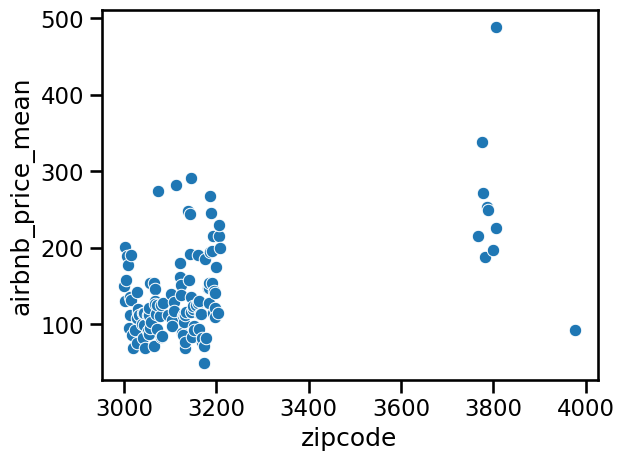

In [ ]:
# Mostrar un gráfico zipcode vs airbnb_price_median
# No se aclara con respecto a que df

sns.scatterplot(x=airbnb_price_by_zipcode_filtered['zipcode'], y=airbnb_price_by_zipcode_filtered['airbnb_price_mean'])

  4. Investigar al menos otras 2 variables que puedan servir para combinar los datos, y justificar si serían adecuadas o no. Pueden asumir que cuentan con la ayuda de anotadores expertos para encontrar equivalencias entre barrios o direcciones, o que cuentan con algoritmos para encontrar las n ubicaciones más cercanas a una propiedad a partir de sus coordenadas geográficas. **NO** es necesario que realicen la implementación.

Como ambos datasets tienen el barrio como variable se podria combinar en base a ello utilizando un relevamiento a cargo de los expertos de la ciudad de Melbourne, Victoria.
Esto seria mas preciso que lo realizado en clase ya que en un zipcode especifico se incluyen varios suburbios/barrios. Aqui se podria estudiar como dos barrios aledaños pueden diferir fuertemente de valor debido a caracteristicas socioculturales de la ciudad en cuestion.

  5. Si las coordenadas geoespaciales estuvieran disponibles, como las usarian?

  
En el caso de tener las coordenadas geoespaciales a disposicion, recomendamos realizar un analisis de imputacion de k-vecinos para predecir valores de las propiedades en estudio. Este se corresponde con el caso ideal ya que se combinaria exactamente la misma propiedad en los dos datasets.

¿Qué cosas no están en los datos que te gustaría tener para predecir mejor el precio de una propiedad?

Como mencionamos anteriormente el precio de la propiedad no solo depende de sus caracteristicas propias del terreno sino tambien esta influenciado por su derredor.
Se destacan las siguientes:
* Servicios publicos (conexiones de agua, luz y gas)
* Infraestructura y obra publica realizada por la ciudad como por ejemplo pavimentacion
* Centros comerciales, educativos y de esparcimiento en el barrio
* Conexiones accesibles para la movilidad en auto
* Poca contaminacion ambiental y/o ruidos molestos
* Procedencia,religion y/o clase socioeconomica de los habitantes de la zona

## Ejercicio 3:

Crear y guardar un nuevo conjunto de datos con todas las transformaciones realizadas anteriormente.

In [ ]:
merged_sales_df.to_csv("melb_data_extended_entregable.csv", index=None)

In [ ]:
airbnb_price_by_zipcode_filtered.to_csv("airbnb_data_by_zipcode.csv", index=None)

In [ ]:
from google.colab import files
files.download("melb_data_extended_entregable.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("airbnb_data_by_zipcode.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Ejercicios opcionales:

1. Armar un script en python (archivo .py) [ETL](https://towardsdatascience.com/what-to-log-from-python-etl-pipelines-9e0cfe29950e) que corra los pasos de extraccion, transformacion y carga, armando una funcion para cada etapa del proceso y luego un main que corra todos los pasos requeridos.

2. Armar un DAG en Apache Airflow que corra el ETL. (https://airflow.apache.org/docs/apache-airflow/stable/tutorial.html)